# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")
data.head(100)



,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0
...,...,...,...
95,1 Topping,2017-07-05,0.0
96,1 Topping,2017-07-06,0.0
97,1 Topping,2017-07-07,0.0
98,1 Topping,2017-07-08,0.0


Esto se hizo con la finalidad de revisar si hay datos faltantes para cada hora es importante saber que todos los sabores estuvieran

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


### Punto 1

In [102]:
conteo_productos = (
    data["Product"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False, sort=False)
)

print(conteo_productos.to_string())

Product
1 Topping                           183
1 Topping Staff                     183
1 Toppings St                       183
3 Topping                           183
3 Topping Staff                     183
Apricot                             183
Apricot ST                          183
Apricot Staff                       183
Asia Research Free Scoop            183
Banana Caramel  /                   183
Banana Caramel St                   183
Banana Staff                        183
Building Promotion                  183
Chai Tea                            183
Chai Tea Staff                      183
Chai Tea st                         183
Cherry Alm Staff                    183
Cherry Almond                       183
Cherry Almond Fudge st              183
Chocoate Cookies                    183
Chocolate                           183
Chocolate St                        183
Chocolate Staff                     183
Coffee                              183
Coffee  St                      

/var/folders/7f/p0j_fkfd1030f_1fg3779m500000gn/T/ipykernel_24431/2092396175.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


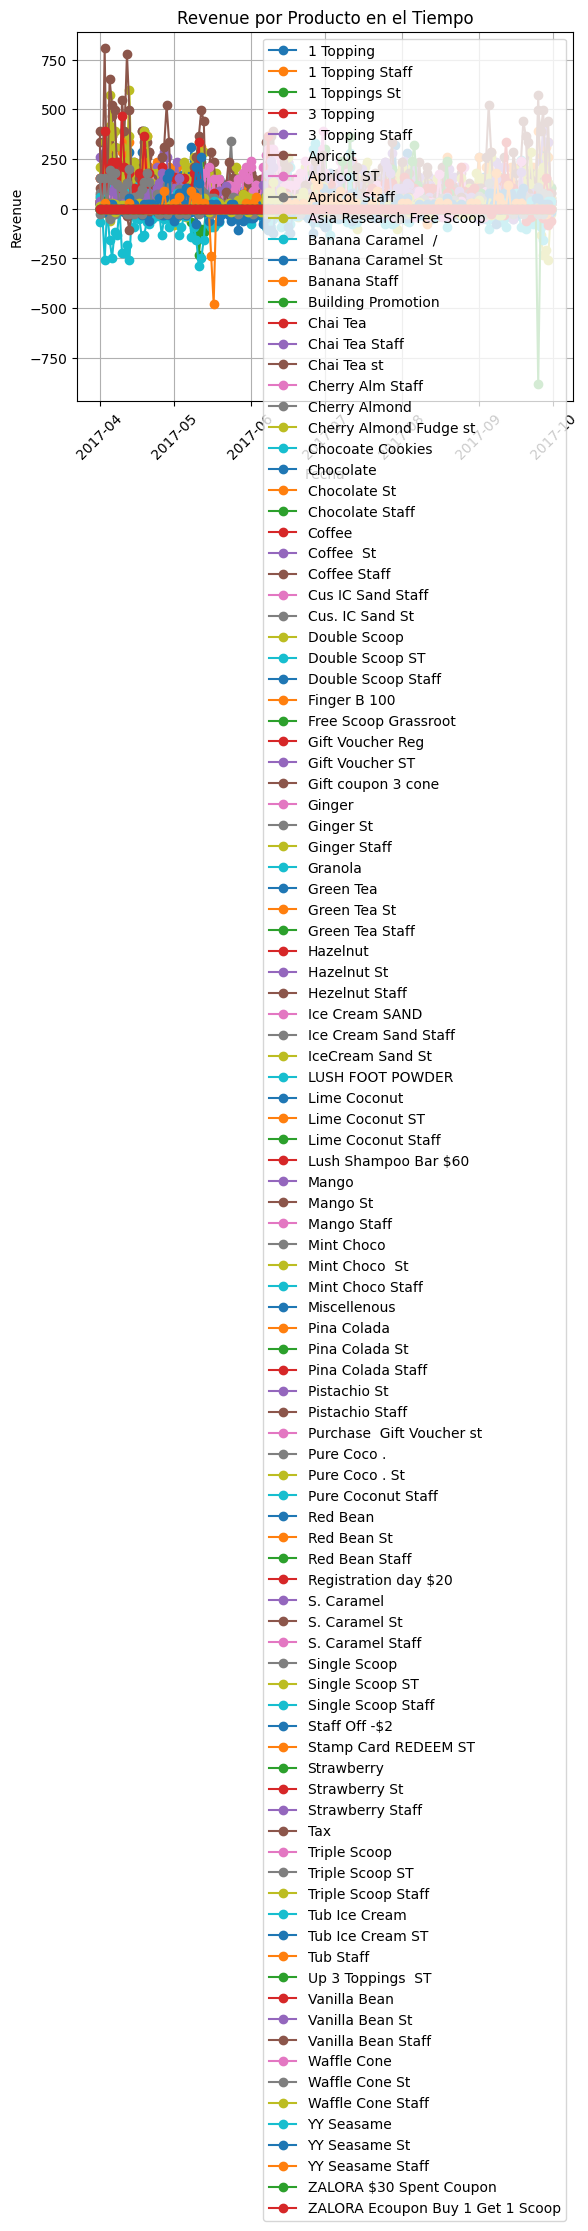

In [103]:
data["Date_clean"] = pd.to_datetime(data["Date_clean"])

for producto in data["Product"].unique():
    filtro = data[data["Product"] == producto]
    plt.plot(filtro["Date_clean"], filtro["Revenue"], marker="o", label=producto)

plt.title("Revenue por Producto en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import re
import json
import os
import webbrowser

# =========================================================
# 1) COPIA Y LIMPIEZA INICIAL
# =========================================================
df = data.copy()

df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Product"] = df["Product"].astype(str).str.strip()
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(subset=["Date_clean", "Product", "Revenue"])

# Guardar nombre original por seguridad
df["Product_original"] = df["Product"]

# =========================================================
# 2) DICCIONARIO DE EQUIVALENCIAS
# =========================================================
EXCEPCIONES_BASE = {
    "1 topping": "1 Topping",
    "1 toppings": "1 Topping",
    "3 topping": "3 Topping",
    "3 toppings": "3 Topping",
    "banana caramel": "Banana Caramel",
    "banana": "Banana Caramel",
    "apricot": "Apricot",
    "chai tea": "Chai Tea",
    "cherry almond": "Cherry Almond",
    "cherry almond fudge": "Cherry Almond Fudge",
    "chocoate cookies": "Chocolate Cookies",
    "chocolate": "Chocolate",
    "coffee": "Coffee",
    "cus ic sand": "Cus IC Sand",
    "cus. ic sand": "Cus IC Sand",
    "double scoop": "Double Scoop",
    "green tea": "Green Tea",
    "hazelnut": "Hazelnut",
    "hezelnut": "Hazelnut",
    "ice cream sand": "Ice Cream Sand",
    "icecream sand": "Ice Cream Sand",
    "lime coconut": "Lime Coconut",
    "mango": "Mango",
    "mint choco": "Mint Choco",
    "miscellenous": "Miscellenous",
    "pina colada": "Pina Colada",
    "pistachio": "Pistachio",
    "pure coco": "Pure Coconut",
    "pure coconut": "Pure Coconut",
    "red bean": "Red Bean",
    "s. caramel": "S. Caramel",
    "single scoop": "Single Scoop",
    "strawberry": "Strawberry",
    "triple scoop": "Triple Scoop",
    "tub": "Tub Ice Cream",
    "tub ice cream": "Tub Ice Cream",
    "up 3 toppings": "Up 3 Toppings",
    "vanilla bean": "Vanilla Bean",
    "waffle cone": "Waffle Cone",
    "yy seasame": "YY Seasame"
}

# =========================================================
# 3) FUNCIÓN PARA LIMPIAR Y CLASIFICAR PRODUCTOS
# =========================================================
def limpiar_producto(prod):
    s = str(prod).strip()

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*/\s*$", "", s)
    s = re.sub(r"\s*\.\s*$", "", s)

    if re.search(r"\bstaff$", s, flags=re.IGNORECASE):
        categoria = "Staff"
        base = re.sub(r"\bstaff$", "", s, flags=re.IGNORECASE).strip()

    elif re.search(r"\bst$", s, flags=re.IGNORECASE):
        categoria = "Student"
        base = re.sub(r"\bst$", "", s, flags=re.IGNORECASE).strip()

    else:
        categoria = "Publico general"
        base = s.strip()

    base = re.sub(r"\s+", " ", base)
    base = re.sub(r"\s*/\s*$", "", base)
    base = re.sub(r"\s*\.\s*$", "", base).strip()

    clave = base.lower()
    base_final = EXCEPCIONES_BASE.get(clave, base)

    producto_mostrado = f"{base_final} - {categoria}"

    return pd.Series([base_final, categoria, producto_mostrado])

df[["Product_base", "Categoria", "Product_limpio"]] = df["Product"].apply(limpiar_producto)
df["Product"] = df["Product_limpio"]

# =========================================================
# 4) AGRUPAR REVENUE YA LIMPIO
# =========================================================
df_grouped = (
    df.groupby(["Date_clean", "Product_base", "Categoria"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Categoria", "Date_clean"])
)

# =========================================================
# 5) TOTAL POR SABOR (suma Staff + Student + Publico general)
# =========================================================
df_total_sabor = (
    df_grouped.groupby(["Date_clean", "Product_base"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Date_clean"])
)
df_total_sabor["Categoria"] = "Total categoria"

# =========================================================
# 6) TOTAL GENERAL DE TODO
# =========================================================
df_total_general = (
    df_grouped.groupby(["Date_clean"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Date_clean")
)

# =========================================================
# 7) CREAR TRAZAS
# =========================================================
sabores = sorted(df_grouped["Product_base"].unique())
categorias_base = ["Publico general", "Student", "Staff"]

fig = go.Figure()
trace_map = {}

for idx, sabor in enumerate(sabores):
    trace_map[sabor] = {}

    # Categorías base
    for categoria in categorias_base:
        temp = df_grouped[
            (df_grouped["Product_base"] == sabor) &
            (df_grouped["Categoria"] == categoria)
        ].sort_values("Date_clean")

        fig.add_trace(
            go.Scatter(
                x=temp["Date_clean"],
                y=temp["Revenue"],
                mode="lines+markers",
                name=categoria,
                visible=(idx == 0)
            )
        )
        trace_map[sabor][categoria] = len(fig.data) - 1

    # Total por sabor
    temp_total = df_total_sabor[
        df_total_sabor["Product_base"] == sabor
    ].sort_values("Date_clean")

    fig.add_trace(
        go.Scatter(
            x=temp_total["Date_clean"],
            y=temp_total["Revenue"],
            mode="lines+markers",
            name="Total categoria",
            visible=False,
            line=dict(dash="dash")
        )
    )
    trace_map[sabor]["Total categoria"] = len(fig.data) - 1

# Traza final: total general
fig.add_trace(
    go.Scatter(
        x=df_total_general["Date_clean"],
        y=df_total_general["Revenue"],
        mode="lines+markers",
        name="Total general",
        visible=False,
        line=dict(width=4)
    )
)
global_trace_index = len(fig.data) - 1

# =========================================================
# 8) DISEÑO BASE
# =========================================================
titulo_inicial = f"Revenue de {sabores[0]} por categoría" if sabores else "Revenue por categoría"

fig.update_layout(
    title=titulo_inicial,
    xaxis_title="Fecha",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    width=1450,
    height=850,
    margin=dict(t=120, r=40, l=60, b=60),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

# =========================================================
# 9) EXPORTAR A HTML
# =========================================================
grafico_html = pio.to_html(
    fig,
    full_html=False,
    include_plotlyjs="cdn",
    div_id="grafico_sabores"
)

options_html = "\n".join(
    [f'<option value="{sabor}">{sabor}</option>' for sabor in sabores]
)

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <title>Gráfico de sabores</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
        }}
        .barra-controles {{
            display: flex;
            gap: 12px;
            align-items: center;
            flex-wrap: wrap;
            margin-bottom: 16px;
        }}
        .barra-controles label {{
            font-weight: bold;
        }}
        .barra-controles select,
        .barra-controles button {{
            padding: 8px 12px;
            font-size: 14px;
            cursor: pointer;
        }}
    </style>
</head>
<body>

<div class="barra-controles">
    <label for="selectorSabor">Sabor:</label>
    <select id="selectorSabor">
        {options_html}
    </select>

    <button id="btnTotalCategoria">Mostrar total categoría</button>
    <button id="btnTotalGeneral">Mostrar total general</button>
</div>

{grafico_html}

<script>
    const sabores = {json.dumps(sabores, ensure_ascii=False)};
    const traceMap = {json.dumps(trace_map, ensure_ascii=False)};
    const globalTraceIndex = {global_trace_index};

    const gd = document.getElementById("grafico_sabores");
    const selector = document.getElementById("selectorSabor");
    const btnTotalCategoria = document.getElementById("btnTotalCategoria");
    const btnTotalGeneral = document.getElementById("btnTotalGeneral");

    let saborActual = sabores.length > 0 ? sabores[0] : null;
    let totalCategoriaVisible = false;
    let vistaTotalGeneral = false;

    function actualizarVista() {{
        const visibles = Array(gd.data.length).fill(false);

        if (vistaTotalGeneral) {{
            visibles[globalTraceIndex] = true;
            Plotly.restyle(gd, "visible", visibles);
            Plotly.relayout(gd, {{
                title: "Revenue total general (suma de todas las categorías)"
            }});

            selector.disabled = true;
            btnTotalCategoria.disabled = true;
            btnTotalGeneral.textContent = "Volver al detalle";
            return;
        }}

        visibles[traceMap[saborActual]["Publico general"]] = true;
        visibles[traceMap[saborActual]["Student"]] = true;
        visibles[traceMap[saborActual]["Staff"]] = true;

        if (totalCategoriaVisible) {{
            visibles[traceMap[saborActual]["Total categoria"]] = true;
        }}

        Plotly.restyle(gd, "visible", visibles);

        Plotly.relayout(gd, {{
            title: totalCategoriaVisible
                ? `Revenue de ${{saborActual}} por categoría + total`
                : `Revenue de ${{saborActual}} por categoría`
        }});

        selector.disabled = false;
        btnTotalCategoria.disabled = false;
        btnTotalCategoria.textContent = totalCategoriaVisible
            ? "Ocultar total categoría"
            : "Mostrar total categoría";
        btnTotalGeneral.textContent = "Mostrar total general";
    }}

    selector.addEventListener("change", function() {{
        saborActual = this.value;
        vistaTotalGeneral = false;
        actualizarVista();
    }});

    btnTotalCategoria.addEventListener("click", function() {{
        if (vistaTotalGeneral) return;
        totalCategoriaVisible = !totalCategoriaVisible;
        actualizarVista();
    }});

    btnTotalGeneral.addEventListener("click", function() {{
        vistaTotalGeneral = !vistaTotalGeneral;
        actualizarVista();
    }});

    actualizarVista();
</script>

</body>
</html>
"""

# Guardar en la misma carpeta
nombre_archivo = "grafico_sabores.html"
with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"Archivo generado: {nombre_archivo}")

# Abrir el archivo local correctamente en el navegador
webbrowser.open("file://" + os.path.abspath(nombre_archivo))

Archivo generado: grafico_sabores.html


True

## Hallazgos observados

* No tiene sentido que **One Scoop**, **Dolce Scoop** y **Triple Scoop** aparezcan como **valores módulo**, porque eso invierte los datos a positivos y puede distorsionar el análisis.

* En **Stamp Card * se observan **pérdidas**.

* **Ice Cream Sand** presenta **valores nulos** desde el **3 de junio** hasta el **25 de junio**.

* **Avellana** muestra una **caída** desde el **20 de mayo** hasta el **13 de junio**.

* **Jengibre**, como se mencionaba en el texto por las creencias chinas, **sube** desde el **13 de mayo** hasta el **31 de mayo**; luego **vuelve a caer**; y entre el **12 de julio** y el **9 de agosto** **presenta otro incremento**.

* **Red Bean** tiene un **comportamiento similar al de productos calientes**, ya que entre el **30 de mayo** y el **21 de junio** se comporta de esa manera.

* **Pistacho** **sube** desde el **5 de junio** hasta el **10 de junio**.

* **Lime Coconut** **sube** desde el **10 de julio** hasta el **29 de julio**; allí presenta una **leve caída**; luego **vuelve a subir** el **10 de agosto**; alcanza su **pico el 19 de agosto**; y después **desciende** hasta el **28 de agosto**.

* **Coffee** **sube** desde el **8 de junio** hasta el **27 de junio** y presenta **valores nulos** desde el **27 de junio** hasta el **6 de julio**.



In [110]:
# =========================================================
# AJUSTE CORRECTO: convertir a positivos
# Single Scoop / Double Scoop / Triple Scoop
# incluyendo ST y Staff
# =========================================================

import re

# Normalizar texto del producto solo para comparar
df["Product_tmp"] = (
    df["Product"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

# Patrón:
# - single scoop
# - double scoop
# - triple scoop
# - con o sin sufijo st / staff
patron_scoops = r"^(single scoop|double scoop|triple scoop)(\s+(st|staff))?$"

mask_invertir = df["Product_tmp"].str.match(patron_scoops, na=False)

# Invertir a positivo
df.loc[mask_invertir, "Revenue"] = pd.to_numeric(
    df.loc[mask_invertir, "Revenue"], errors="coerce"
).abs()

# Verificación
print("Registros ajustados:", mask_invertir.sum())
print(df.loc[mask_invertir, ["Product", "Revenue"]].head(20))

# Limpiar auxiliar
df.drop(columns=["Product_tmp"], inplace=True)

Registros ajustados: 0
Empty DataFrame
Columns: [Product, Revenue]
Index: []


### Punto 2

### Punto 3

### Punto 4